In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [10]:
df = pd.read_csv("/Users/amanbhudia/Documents/Final_Year_Project/CreditCardFraudProject/data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

In [12]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [13]:
df["Class"].value_counts()

df["Class"].value_counts(normalize=True) * 100

# 0(legit)
# 1(Fraud)


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [14]:
fraud_count = df["Class"].value_counts()[1]
legit_count = df["Class"].value_counts()[0]

print(f"Fraud cases: {fraud_count}")
print(f"Legitimate cases: {legit_count}")
print(f"Fraud percentage: {(fraud_count/len(df))*100:.4f}%")

Fraud cases: 492
Legitimate cases: 284315
Fraud percentage: 0.1727%


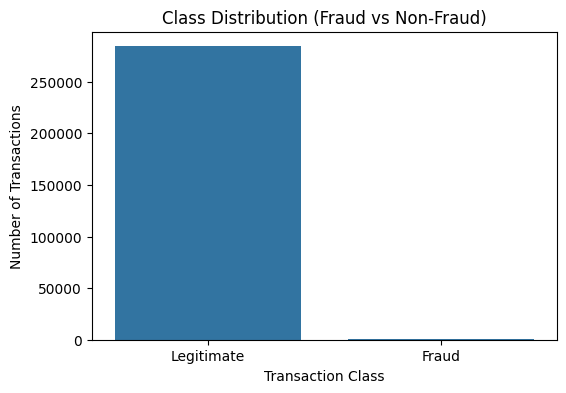

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks([0,1], ["Legitimate", "Fraud"])

plt.show()

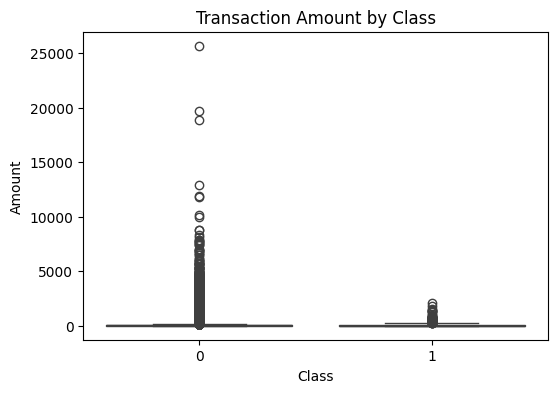

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.show()

Skewness of Amount: 16.977724453761024


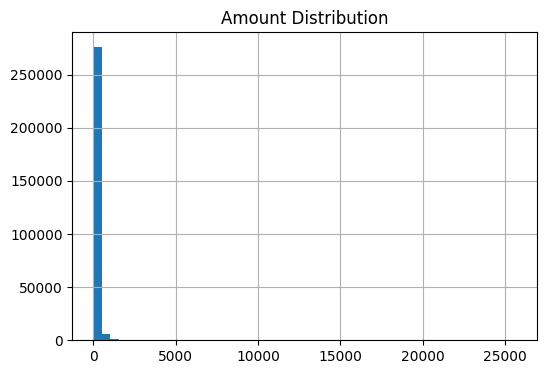

Skewness of Log_Amount: 0.1627029277416401


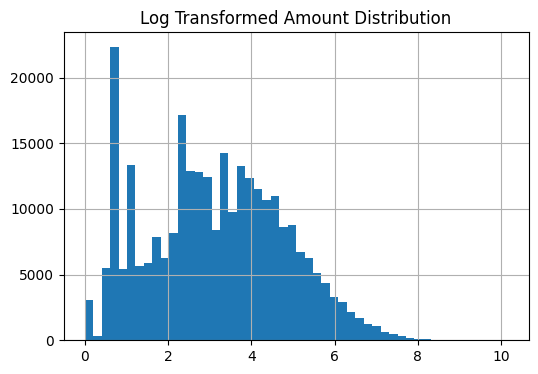

In [15]:
# Calculate skewness for all numeric columns
skew_values = df.skew().sort_values(ascending=False)

skew_values.head(10)

print("Skewness of Amount:", df["Amount"].skew())

plt.figure(figsize=(6,4))
df["Amount"].hist(bins=50)
plt.title("Amount Distribution")
plt.show()

df["Log_Amount"] = np.log1p(df["Amount"])

print("Skewness of Log_Amount:", df["Log_Amount"].skew())

plt.figure(figsize=(6,4))
df["Log_Amount"].hist(bins=50)
plt.title("Log Transformed Amount Distribution")
plt.show()

Top 5 positively correlated features:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
Name: Class, dtype: float64

Top 5 negatively correlated features:
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


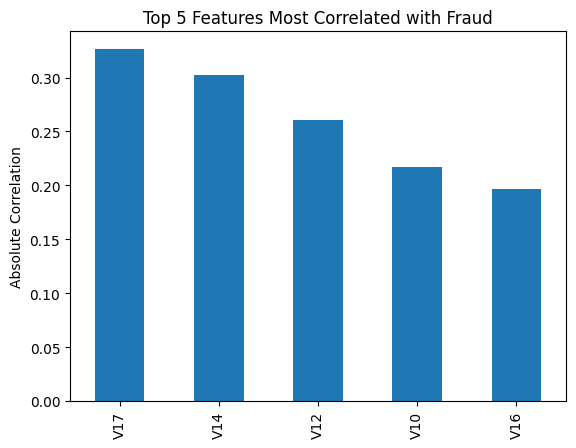

In [16]:
# Correlation of all features with the target variable
corr_with_class = df.corr()["Class"].sort_values(ascending=False)

corr_with_class.head(10)

print("Top 5 positively correlated features:")
print(corr_with_class.head(6))  # includes Class itself

print("\nTop 5 negatively correlated features:")
print(corr_with_class.tail(5))

top_features = corr_with_class.abs().sort_values(ascending=False)[1:6]

top_features.plot(kind="bar")
plt.title("Top 5 Features Most Correlated with Fraud")
plt.ylabel("Absolute Correlation")
plt.show()